Code demos: vowel classification & hearing aid optimization
===========================================================
***A practical introduction to machine learning for hearing science***

<a href="https://colab.research.google.com/github/msaddler/auditory_machine_learning/blob/main/DEMO.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


## Setup

Import standard Python packages.

In [2]:
import IPython.display as ipd
import matplotlib.pyplot as plt
import numpy as np
import torch
import tqdm


If running this notebook in Google Colab, run the bash script below to clone the [**`auditory_machine_learning`**](https://github.com/msaddler/auditory_machine_learning) repository and set the working directory.

In [ ]:
!git clone https://github.com/msaddler/auditory_machine_learning.git
%cd auditory_machine_learning
!ls -1

Import [**example_datasets.py**](https://github.com/msaddler/auditory_machine_learning/blob/main/example_datasets.py), [**example_plots.py**](https://github.com/msaddler/auditory_machine_learning/blob/main/example_plots.py), [**modules.py**](https://github.com/msaddler/auditory_machine_learning/blob/main/modules.py), and [**utils.py**](https://github.com/msaddler/auditory_machine_learning/blob/main/utils.py) as Python modules.

Once imported, the classes and functions in these files can be called from this notebook.

In [3]:
import example_datasets
import example_plots
import modules
import utils

import importlib
importlib.reload(example_datasets)
importlib.reload(example_plots)
importlib.reload(modules)
importlib.reload(utils)


Check if a GPU is available in the current runtime and define the `device` variable.

In [41]:
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print(f"Available device: {device}")

if device.type == "cpu":
    # Use a smaller cochlear model to make code run faster if GPU is unavailable
    config_cochlear_model = {
        "sr_output": 1000,
        "ihc_lowpass_cutoff": 100,
    }
else:
    config_cochlear_model = {}


Available device: cpu


## Introduction

This repository includes two small audio datsets, which can be loaded and played in the notebook.

In [42]:
# Dataset of synthetic vowel sounds
vowel_dataset = example_datasets.SyntheticVowels(
    sr=20000,   # Sampling rate in Hz
    dur=0.250,  # Stimulus duration in s
    dbspl=60,   # Stimulus level in dB SPL
    f0=100,     # Fundamental frequency in Hz
)

example = vowel_dataset[0]
print("Indexing into `vowel_dataset` yields a dictionary with key-value pairs:")
for k, v in example.items():
    print(f"|__ {k}: {v}")
print("The `signal` is the sound waveform in Pa sampled at `sr` Hz\n")

# Iterate over the dataset and play example vowels
for itr in range(10):
    example = vowel_dataset[itr]
    sr = example["sr"]
    x = example["signal"]
    print(f'{example["vowel"]}  |  {example["vowel_str"]}  |  f0 = {example["f0"]}Hz')
    ipd.display(ipd.Audio(rate=sr, data=x))


Indexing into `vowel_dataset` yields a dictionary with key-value pairs:
|__ sr: 20000
|__ signal: [-0.00250599 -0.00250599 -0.00250599 ... -0.00250578 -0.00250592
 -0.00250599]
|__ dbspl: 60.0
|__ f0: 100.0
|__ formants: [ 325 2900 3500]
|__ vowel: 0
|__ vowel_str: /i/ (heed)
The `signal` is the sound waveform in Pa sampled at `sr` Hz

0  |  /i/ (heed)  |  f0 = 100.0Hz


1  |  /I/ (hid)  |  f0 = 100.0Hz


2  |  /e/ (hayed)  |  f0 = 100.0Hz


3  |  /eps/ (head)  |  f0 = 100.0Hz


4  |  /ae/ (had)  |  f0 = 100.0Hz


5  |  /a/ (hod)  |  f0 = 100.0Hz


6  |  /^/ (hud)  |  f0 = 100.0Hz


7  |  /o/ (hoed)  |  f0 = 100.0Hz


8  |  /U/ (hood)  |  f0 = 100.0Hz


9  |  /u/ (who'd)  |  f0 = 100.0Hz


In [43]:
# Dataset of speech recordings saved as WAV files
speech_dataset = example_datasets.WavFiles(
    sr=20000,                # Sampling rate in Hz
    dur=2.0,                 # Stimulus duration in s
    filenames="data/*.wav",  # Filenames to include in the dataset
    dbspl=60,                # Stimulus level in dB SPL
)

example = speech_dataset[0]
print("Indexing into `speech_dataset` yields a dictionary with key-value pairs:")
for k, v in example.items():
    print(f"|__ {k}: {v}")
print("The `signal` is the sound waveform in Pa sampled at `sr` Hz\n")

# Iterate over the dataset and play example speech clips
for itr in range(4):
    idx = np.random.randint(len(speech_dataset))
    example = speech_dataset[idx]
    sr = example["sr"]
    x = example["signal"]
    print(example["filename"])
    ipd.display(ipd.Audio(rate=sr, data=x))


Indexing into `speech_dataset` yields a dictionary with key-value pairs:
|__ sr: 20000
|__ signal: [0.00196841 0.00251773 0.00367739 ... 0.00563052 0.00791933 0.00831606]
|__ dbspl: 60
|__ filename: data/000.wav
The `signal` is the sound waveform in Pa sampled at `sr` Hz

data/089.wav


data/047.wav


data/098.wav


data/084.wav


## Cochlear model

The [**`modules`**](https://github.com/msaddler/auditory_machine_learning/blob/main/modules.py) file contains a `CochlearModel` class, which implements a simple cochlear model as a PyTorch module.

We can call this class to construct the PyTorch model object and inspect it.


In [44]:
cochlear_model = modules.CochlearModel(
    sr_input=20000,                     # Sampling rate of input audio (Hz)
    sr_output=10000,                    # Sampling rate of output auditory nerve representations (Hz)
    fir_dur=0.05,                       # Cochlear filterbank FIR duration (s)
    cfs=utils.erbspace(8e1, 8e3, 100),  # Characteristic frequencies (Hz)
    bw_mult=1.0,                        # Scaling factor to broaden/narrow bandwidths of cochlear filters
    ihc_lowpass_cutoff=3000,            # Inner hair cell lowpass filter cutoff determines phase locking limit (Hz)
    ihc_lowpass_order=7,                # Inner hair cell lowpass filter order (int)
    threshold=0.0,                      # Absolute threshold of auditory nerve fibers (dB SPL)
    dynamic_range=80.0,                 # Dynamic range of auditory nerve fibers (dB)
    dtype=torch.float32,                # Default PyTorch datatype
)
print(cochlear_model)


CochlearModel(
  (cochlear_filterbank): GammatoneFilterbank()
  (half_wave_rectification): ReLU()
  (ihc_lowpass_filter): IHCLowpassFilter()
  (rate_level_function): SigmoidRateLevelFunction()
)


The `cochlear_model` object can be called on an input sound waveform to generate a simulated auditory nerve representation.

The [**`utils`**](https://github.com/msaddler/auditory_machine_learning/blob/main/utils.py) file contains helper functions like `make_nervegram_plot`, which we can use to visualize the simulated nerve representation.

/Users/marksa/Desktop/auditory_machine_learning/utils.py:152: RuntimeWarning: divide by zero encountered in log10
  pxx = 10.0 * np.log10(pxx / np.square(p_ref))


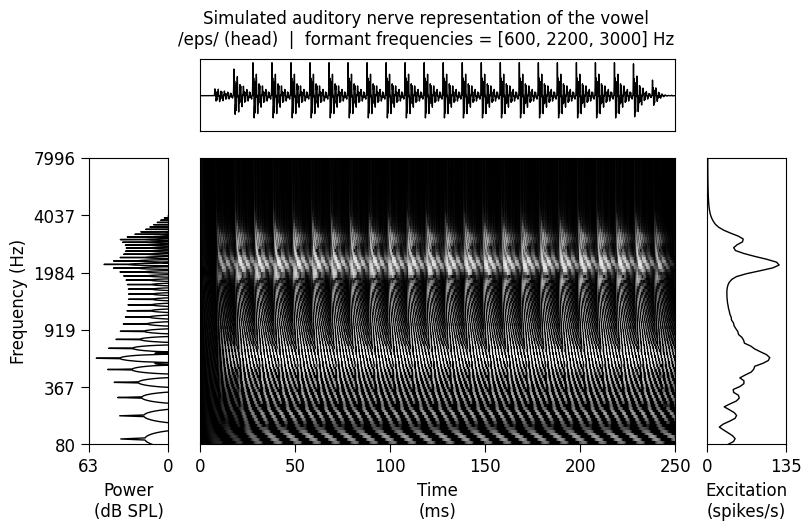

In [45]:
example = vowel_dataset[3]
# example = vowel_dataset[np.random.randint(len(vowel_dataset))]
waveform = torch.as_tensor(example["signal"])  # <-- converts a NumPy array to a PyTorch tensor 
nervegram = cochlear_model(waveform)

fig, ax_arr = utils.make_nervegram_plot(
    waveform=waveform.numpy(),  # <-- .numpy() converts a PyTorch tensor back to a NumPy array
    nervegram=nervegram.numpy(),
    sr_waveform=cochlear_model.sr_input,
    sr_nervegram=cochlear_model.sr_output,
    cfs=cochlear_model.cfs,
)
s = f"{example['vowel_str']}  |  formant frequencies = {[int(_) for _ in example['formants']]} Hz"
fig.suptitle(f"Simulated auditory nerve representation of the vowel\n{s}")
plt.show()


The following cell visualizes the input-output functions of each stage of the simplistic cochlear model.

/Users/marksa/Desktop/auditory_machine_learning/utils.py:152: RuntimeWarning: divide by zero encountered in log10
  pxx = 10.0 * np.log10(pxx / np.square(p_ref))


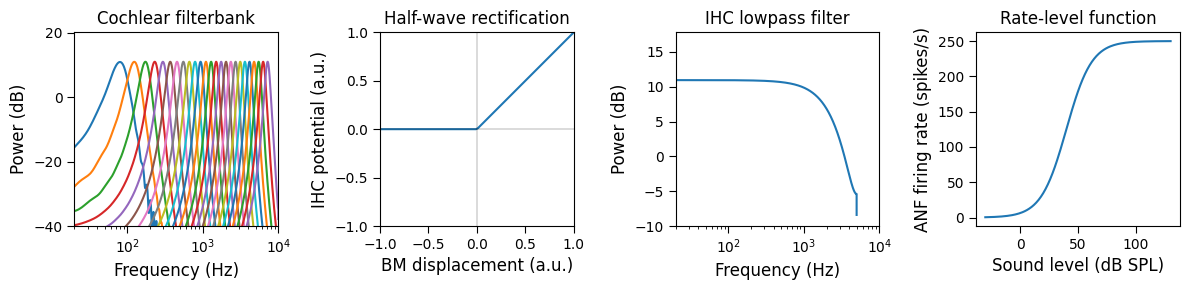

In [11]:
fig, ax_arr = example_plots.visualize_cochlear_model_stages(cochlear_model)


To get a better sense of the cochlear model, we can successively apply each model stage to an input sound and plot the output after each stage.

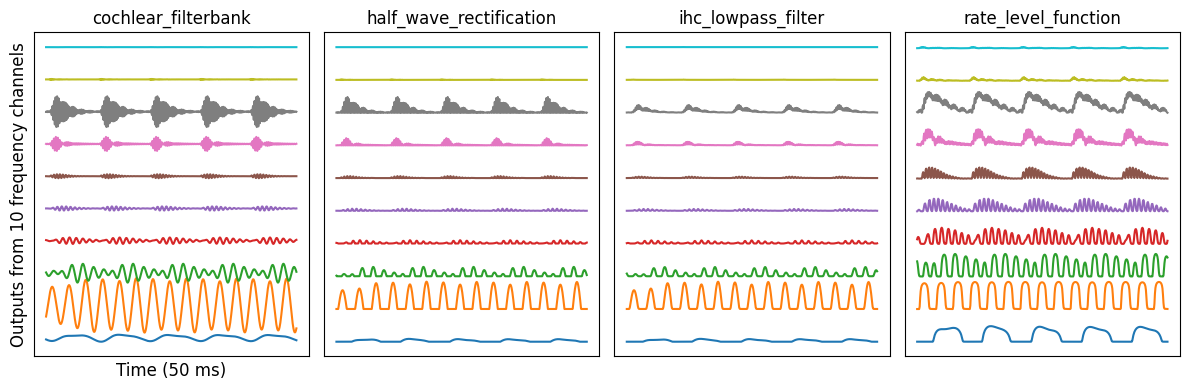

In [46]:
fig, ax_arr = example_plots.visualize_cochlear_model_stage_outputs(
    cochlear_model,
    example_input=vowel_dataset[0]["signal"],
)


## Simulating hearing loss

As constructed, the `cochlear_model` object simulates peripheral auditory processing in a healthy ear.

How might we modify it to model the peripheral consequences of hearing loss?


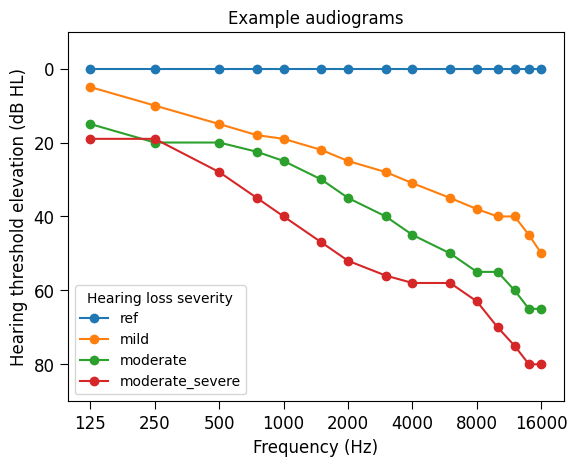

In [47]:
fig, ax = plt.subplots()
for severity in ["ref", "mild", "moderate", "moderate_severe"]:
    audiogram = utils.get_example_audiogram(severity)
    ax.plot(audiogram["freq"], audiogram["dbhl"], marker="o", label=severity)
ax.legend(title="Hearing loss severity")
ax = utils.format_axes(
    ax,
    xscale="log",
    ylimits=[90, -10],
    xticks=[125, 250, 500, 1000, 2000, 4000, 8000, 16000],
    xticklabels=[125, 250, 500, 1000, 2000, 4000, 8000, 16000],
    xticks_minor=[],
    str_xlabel="Frequency (Hz)",
    str_ylabel="Hearing threshold elevation (dB HL)",
    str_title="Example audiograms",
)
plt.show()


In the healthy ear, outer hair cells (OHCs) act as a cochlear amplifier, boosting responses to quiet sounds. Sensorineural hearing loss often involves the death or dysfunction of OHCs, resulting in reduced sensitivity to quiet sounds (elevated thresholds) and a smaller dynamic range. One way we can crudely simulate these effects is by adjusting the rate-level function parameters.

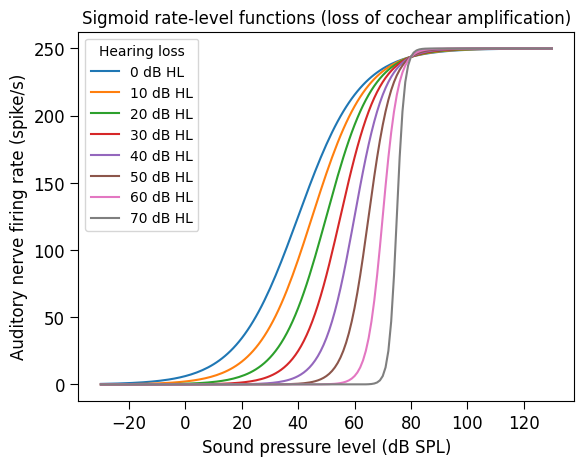

In [14]:
fig, ax = plt.subplots()
healthy_threshold = 0.0
healthy_dynamic_range = 80.0
for dbhl in np.arange(0, 71, 10):
    rate_level_function = modules.SigmoidRateLevelFunction(
        threshold=healthy_threshold + dbhl,          # OHC loss increases the threshold
        dynamic_range=healthy_dynamic_range - dbhl,  # and decreases the dynamic range
    )
    x_db = torch.arange(-30, 131)
    x_pa = 20e-6 * (10 ** (x_db / 20))
    y = rate_level_function(x_pa)
    ax.plot(x_db.numpy(), y.numpy(), label=f"{dbhl} dB HL")
ax.legend(title="Hearing loss")
ax = utils.format_axes(
    ax,
    str_xlabel="Sound pressure level (dB SPL)",
    str_ylabel="Auditory nerve firing rate (spike/s)",
    str_title="Sigmoid rate-level functions (loss of cochear amplification)",
)
plt.show()


The [**`modules`**](https://github.com/msaddler/auditory_machine_learning/blob/main/modules.py) file contains an `AudiogramMatchedCochlearModel` class, which is a sub-class of `CochlearModel`. This class is constructed from an audiogram (a Python `dict` of the form `{"freq": [...], "dbhl": [...]}`). The audiogram is used to set cochlear model parameters in a frequency-dependent manner.


/Users/marksa/Desktop/auditory_machine_learning/utils.py:152: RuntimeWarning: divide by zero encountered in log10
  pxx = 10.0 * np.log10(pxx / np.square(p_ref))


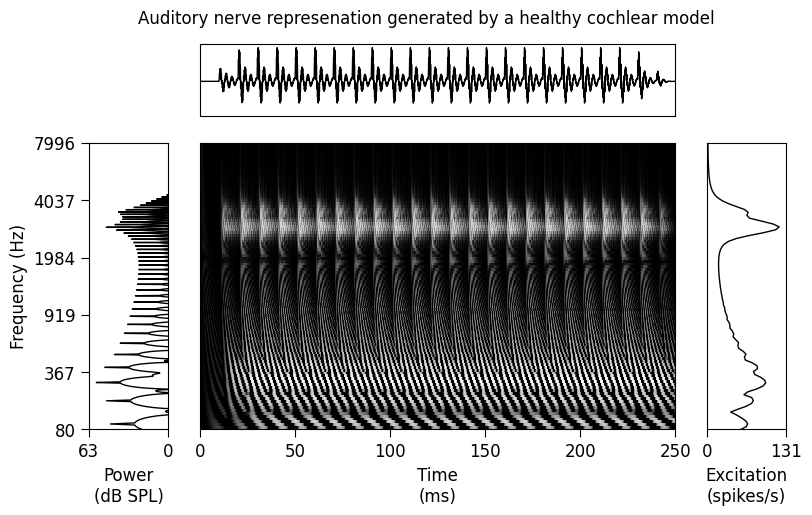

/Users/marksa/Desktop/auditory_machine_learning/utils.py:152: RuntimeWarning: divide by zero encountered in log10
  pxx = 10.0 * np.log10(pxx / np.square(p_ref))


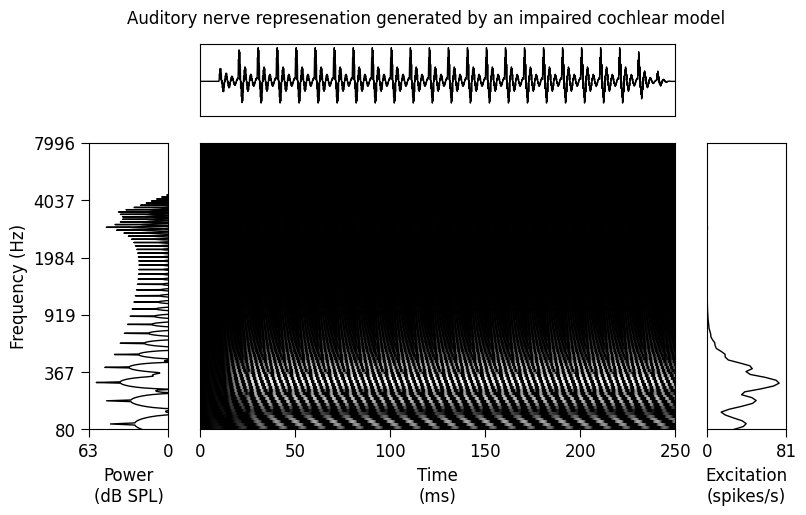

In [15]:
audiogram_healthy = utils.get_example_audiogram("ref")
# audiogram_impaired = utils.get_example_audiogram("mild")
# audiogram_impaired = utils.get_example_audiogram("moderate")
audiogram_impaired = utils.get_example_audiogram("moderate_severe")
# audiogram_impaired = {
#     "freq": [125, 250, 500, 1000, 2000, 4000, 8000],
#     "dbhl": [0, 0, 50, 0, 0, 0, 0],
# }
cochlear_model_healthy = modules.AudiogramMatchedCochlearModel(audiogram=audiogram_healthy)
cochlear_model_impaired = modules.AudiogramMatchedCochlearModel(audiogram=audiogram_impaired)

vowel_dataset = example_datasets.SyntheticVowels()
example_input = vowel_dataset[0]["signal"]

fig, ax_arr = example_plots.visualize_cochlear_model(
    cochlear_model=cochlear_model_healthy,
    example_input=example_input,
    str_title="Auditory nerve represenation generated by a healthy cochlear model",
)
fig, ax_arr = example_plots.visualize_cochlear_model(
    cochlear_model=cochlear_model_impaired,
    example_input=example_input,
    str_title="Auditory nerve represenation generated by an impaired cochlear model",
)


**The cochlear model used here is only a crude simulation of the auditory periphery**. It does not capture many of the intricacies of real auditory nerve responses (such as level-dependent frequency tuning and firing rate adaptation). Here, we have decided to neglect many of complexities in favor of a model that runs fast and can be differentiably implemented in PyTorch.

The cell below gives a sense of how fast the cochlear model can run on the current device.

In [17]:
cochlear_model = modules.AudiogramMatchedCochlearModel(audiogram="ref", **config_cochlear_model).to(device)

dataset = example_datasets.WavFiles() # <-- Dataset of 2 s speech clips
# dataset = example_datasets.SyntheticVowels()  # <-- Dataset of 250 ms synthetic vowels

progress_bar = tqdm.tqdm(range(100))  # tqdm.tqdm wraps an iterable to display a progress bar
for itr in progress_bar:
    example = dataset[np.random.randint(len(dataset))]
    x = torch.as_tensor(example["signal"]).to(device)
    x_nervegram = cochlear_model(x)
    progress_bar.set_postfix({"current_iteration": itr})  # <-- customize text in the progress bar



00%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 100/100 [00:10<00:00,  9.44it/s, current_iteration=99]

## Hearing aid optimization objective

A reasonable objective for a hearing aid would be to process audio in such a way that the auditory nerve representation of an impaired ear is maximally similar to that of a healthy ear. How can we implement this notion quantitatively as a *loss function*?

We define a `cochlear_model_loss_function` that takes as input an unprocessed sound waveform (`x_unprocessed`) and a processed sound_waveform (`x_processed`). The unprocessed input is passed through a model of a healthy ear and the processed input is passed through a model of the impaired ear. We then calculate a [**measure of distance**](https://pytorch.org/docs/stable/nn.functional.html#loss-functions) between the healthy auditory nerve representation of `x_unprocessed` and the impaired auditory nerve representation of `x_processed`.


In [18]:
cochlear_model_healthy = modules.AudiogramMatchedCochlearModel(audiogram="ref", **config_cochlear_model).to(device)
cochlear_model_impaired = modules.AudiogramMatchedCochlearModel(audiogram="moderate_severe", **config_cochlear_model).to(device)

def cochlear_model_loss_function(x_unprocessed, x_processed):
    """ """
    # Run unprocessed and processed sounds through cochlear models
    x_nervegram_healthy = cochlear_model_healthy(x_unprocessed)
    x_nervegram_impaired = cochlear_model_impaired(x_processed)

    # Define the loss as the mean squared error between the
    # healthy and impaired auditory nerve representations.
    # Other distance metrics are possible (RMSE, MAE, etc).
    loss = torch.nn.functional.mse_loss(
        x_nervegram_impaired,
        x_nervegram_healthy,
    )
    return loss


We will first consider the **simplest possible hearing aid**: linear amplification applied uniformly to the entire sound waveform. Here, there is only a single parameter to optimize (the gain), so we can find the optimal value via brute force.


gain_db=-22.5 --> loss=5191.0215
gain_db=-17.5 --> loss=5327.5493
gain_db=-12.5 --> loss=5239.7139
gain_db=-7.5 --> loss=3842.9475
gain_db=-2.5 --> loss=4243.7515
gain_db=2.5 --> loss=3307.0688
gain_db=7.5 --> loss=2091.1008
gain_db=12.5 --> loss=1746.9523
gain_db=17.5 --> loss=1354.3982
gain_db=22.5 --> loss=1692.6511
gain_db=27.5 --> loss=2641.9685
gain_db=32.5 --> loss=4326.0259
gain_db=37.5 --> loss=7397.4517
gain_db=42.5 --> loss=10308.3281
gain_db=47.5 --> loss=13860.7783


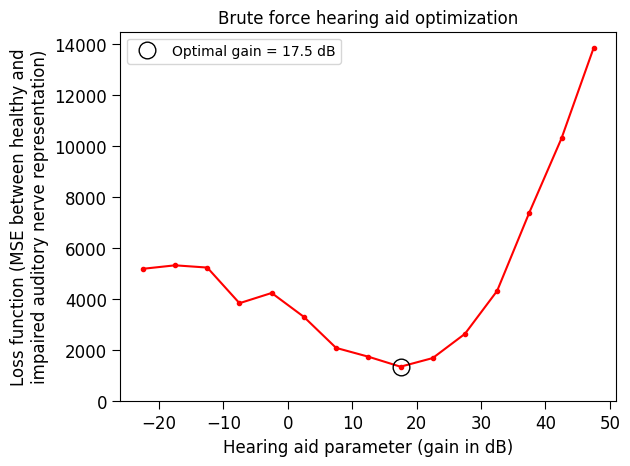

In [22]:
# Define a training dataset and use the torch DataLoader class to handle batching / shuffling
# dataset_train = example_datasets.WavFiles(filenames="data/???.wav", dbspl=60)
dataset_train = example_datasets.SyntheticVowels(f0=(100, 400), dbspl=(60, 60), n_examples=10)
dataloader_train = torch.utils.data.DataLoader(dataset_train, batch_size=16, shuffle=True)

# Iterate over a list of candidate gain_db values
list_gain_db = np.arange(-22.5, 50.1, 5)
list_loss = []
for gain_db in list_gain_db:
    # For each gain_db value, compute the average loss across the full dataset
    loss = 0
    for step, example in enumerate(dataloader_train):
        x_unprocessed = example["signal"].to(device)
        x_processed = x_unprocessed * np.power(10, gain_db / 20)
        batch_loss = cochlear_model_loss_function(x_unprocessed, x_processed).item()
        loss += batch_loss
    loss = loss / len(dataloader_train)
    list_loss.append(loss)
    print(f"{gain_db=:.1f} --> {loss=:.4f}")

# The optimal gain is the one producing the lowest loss value
best_gain_db = list_gain_db[np.argmin(list_loss)]

fig, ax = plt.subplots()
ax.plot(list_gain_db, list_loss, marker=".", color="r", ls="-")
ax.plot(
    best_gain_db,
    np.min(list_loss),
    marker="o",
    ms=12,
    ls="",
    mfc="none",
    color="k",
    label=f"Optimal gain = {best_gain_db} dB",
)
ax.legend()
utils.format_axes(
    ax,
    str_title="Brute force hearing aid optimization",
    str_xlabel="Hearing aid parameter (gain in dB)",
    str_ylabel="Loss function (MSE between healthy and\nimpaired auditory nerve representation)",
    ylimits=[0, None],
)
plt.show()


## Gradient-based hearing aid optimization 

Brute force optimization is useful, but it does not scale well as the number of parameters increases. Gradient-based optimization is the workhorse of machine learning because it does scale well. Here, we implement the same one parameter hearing aid as a PyTorch module with a single trainable parameter (the gain applied to the entire sound waveform). We will optimize this parameter aid using gradient descent to minimize our loss function.

**This cell will run extremely slowly without GPU acceleration**. If a GPU is not available, consider making the stimuli/dataset and cochlear models smaller.


In [24]:
class UniformGainHearingAid(torch.nn.Module):
    def __init__(self, initial_gain_db=0):
        """
        Initialize the hearing aid model.
        """
        super().__init__()
        self.gain_db = torch.nn.parameter.Parameter(
            data=torch.ones([]) * initial_gain_db,
            requires_grad=True,
        )

    def forward(self, x):
        """
        Apply hearing aid processing to an input sound `x`.
        """
        return x * torch.pow(10, self.gain_db / 20)

    def __repr__(self):
        """ """
        gain_db = self.gain_db.detach().cpu().numpy()
        return f"HearingAid({gain_db=:.2f})"


# Dataset and dataloader are the same as used in the brute force optimization
# dataset_train = example_datasets.WavFiles(filenames="data/???.wav", dbspl=60)
dataset_train = example_datasets.SyntheticVowels(f0=(100, 400), dbspl=(60, 60), n_examples=100)
dataloader_train = torch.utils.data.DataLoader(dataset_train, batch_size=16, shuffle=True)

# Initialize the hearing_aid object and assign it to the device
hearing_aid = UniformGainHearingAid(initial_gain_db=0).to(device)

# Define an optimizer object in PyTorch (implements a gradient descent algorithm)
optimizer = torch.optim.Adam(
    params=hearing_aid.parameters(),  # Tells the optimizer which parameters to optimize
    lr=1e-0,  # The learning rate is a hyperparameter (determines gradient descent step size)
)

print(f"Before optimization: {hearing_aid}\n\n")

# Loop over the dataset num_epochs times
num_epochs = 10
progress_bar = tqdm.tqdm(range(num_epochs))
for epoch in progress_bar:
    loss = 0

    # Iterate over each batch in the dataloader
    for step, example in enumerate(dataloader_train):

        # The `forward pass` to compute the loss is the same as in the brute force optimization
        x_unprocessed = example["signal"].to(device)
        x_processed = hearing_aid(x_unprocessed)
        batch_loss = cochlear_model_loss_function(x_unprocessed, x_processed)

        # The new additions are in the `backward pass`
        optimizer.zero_grad()  # <-- reset gradients from the previous step
        batch_loss.backward()  # <-- compute gradients of the loss w.r.t to the trainable parameter(s)
        optimizer.step()  # <-- update parameter(s) by taking a "step" in the direction that minimizes the loss

        loss += batch_loss.item()  # Keep track of the running loss to display in the progress bar
        progress_bar.set_postfix({
            "loss": f"{loss / (step + 1):.2f}",
            "hearing_aid": str(hearing_aid),
        })

print(f"\n\nAfter optimization: {hearing_aid}")


Before optimization: HearingAid(gain_db=0.00)




100%|█████████████████████████████████████████████████████████████████████████████████████| 10/10 [00:25<00:00,  2.60s/it, loss=1260.43, hearing_aid=HearingAid(gain_db=19.30)]



After optimization: HearingAid(gain_db=19.30)


Visualize the effects of the optimized hearing aid processing on the auditory nerve representations.

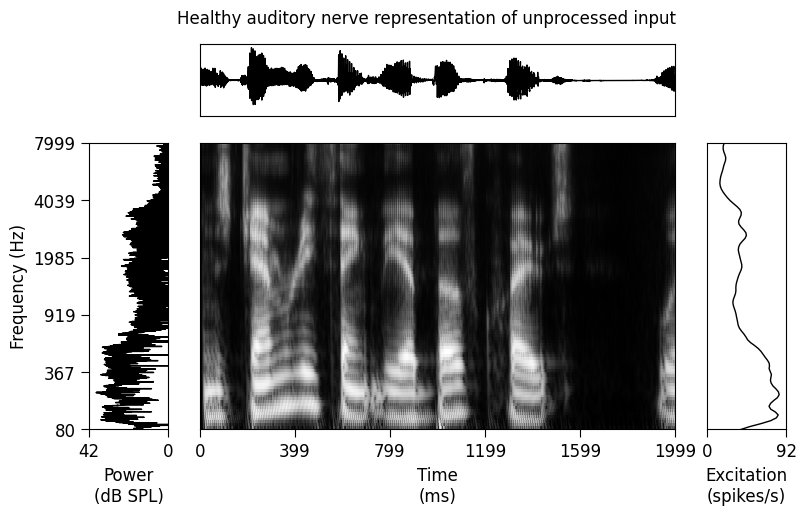

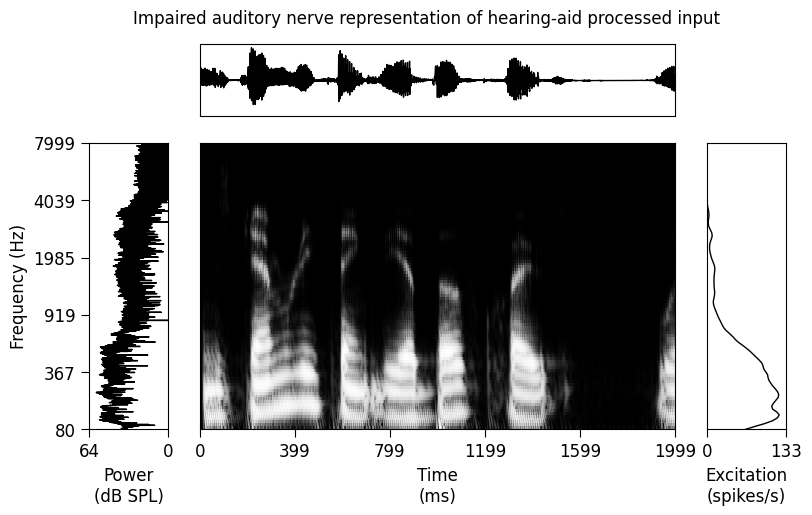

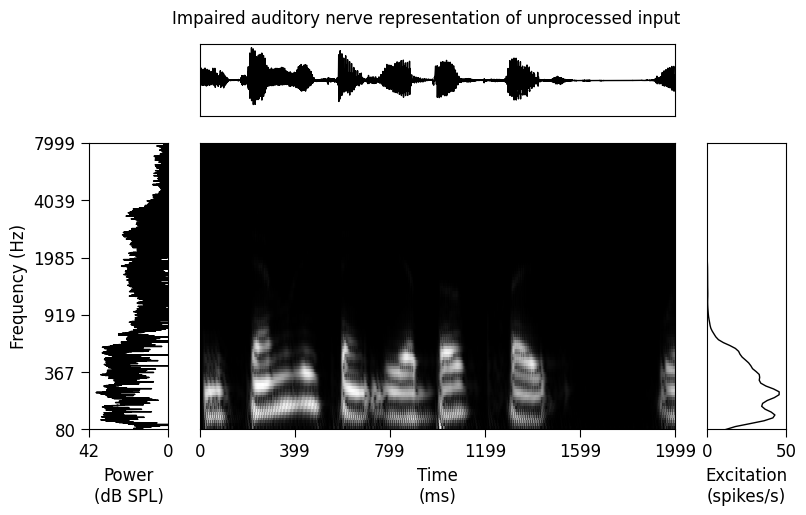

In [28]:
example_input = torch.as_tensor(example_datasets.WavFiles()[0]["signal"]).to(device)

fig, ax_arr = example_plots.visualize_cochlear_model(
    cochlear_model=cochlear_model_healthy,
    example_input=example_input,
    str_title="Healthy auditory nerve representation of unprocessed input",
)
fig, ax_arr = example_plots.visualize_cochlear_model(
    cochlear_model=cochlear_model_impaired,
    example_input=hearing_aid(example_input),
    str_title="Impaired auditory nerve representation of hearing-aid processed input",
)
fig, ax_arr = example_plots.visualize_cochlear_model(
    cochlear_model=cochlear_model_impaired,
    example_input=example_input,
    str_title="Impaired auditory nerve representation of unprocessed input",
)


The impaired auditory nerve representation is closer to the healthy auditory nerve representation but not by much. Applying a single gain to the entire sound waveform is not a good solution for real hearing losses, which are rarely uniform across all frequencies. How can we compensate for frequency-dependent hearing loss?

## Frequency-dependent amplification

One possibility is to build a hearing aid with frequency-specific gains. We can filter the input sound into different frequency channels, scale each channel with a separate gain, and then sum the channels back together. The `modules.HalfCosineFilterbank` class is a useful filterbank for decomposing and reconstructing audio in this way.

/Users/marksa/Desktop/auditory_machine_learning/modules.py:416: RuntimeWarning: divide by zero encountered in log
  f = np.log(f)


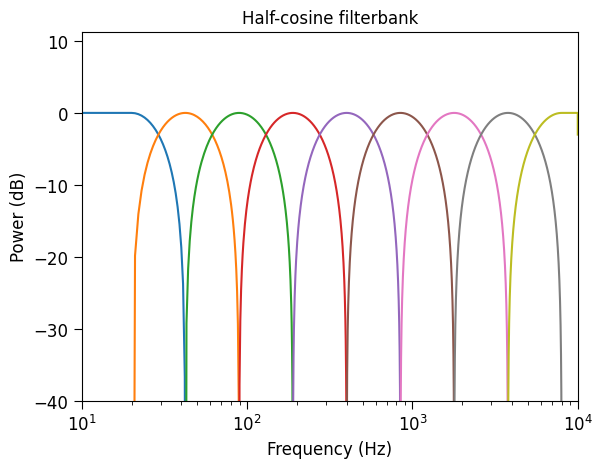

In [29]:
sr = 20000
filterbank = modules.HalfCosineFilterbank(
    sr=sr,
    cf_low=20,
    cf_high=8000,
    cf_num=9,
    scale="log",
    include_highpass=True,
    include_lowpass=True,
)

impulse = torch.zeros(int(sr))
impulse[0] = 1
impulse_response = filterbank(impulse).numpy()

fig, ax = plt.subplots()
fxx, pxx = utils.periodogram(impulse_response, sr)
ax.plot(fxx, pxx.T - pxx.max())
ax = utils.format_axes(
    ax,
    str_title="Half-cosine filterbank",
    str_xlabel="Frequency (Hz)",
    str_ylabel="Power (dB)",
    xscale="log",
    xlimits=[10, sr // 2],
    ylimits=[-40, None],
)
plt.show()


In the following cell, we implement and optimize a hearing aid with frequency specific gains. While the `UniformGainHearingAid` above has only a single gain parameter, the `FrequencySpecificGainHearingAid` has a separate gain parameter for each frequency channel. Brute force optimization would require searching over all possible combinations of these frequency-specific gains. Gradient-based optimization is much more efficient.

In [30]:
class FrequencySpecificGainHearingAid(torch.nn.Module):
    def __init__(self, sr=20000, num_channels=9, initial_gain_db=0):
        """
        Initialize the hearing aid model.
        """
        super().__init__()
        self.sr = sr
        self.num_channels = num_channels
        self.filterbank = modules.HalfCosineFilterbank(
            sr=self.sr,
            cf_low=20,
            cf_high=self.sr // 2,
            cf_num=self.num_channels,
            scale="log",
            include_highpass=True,
            include_lowpass=True,
        )
        self.gain_db = torch.nn.parameter.Parameter(
            data=torch.ones(num_channels) * initial_gain_db,
            requires_grad=True,
        )

    def forward(self, x):
        """
        Apply hearing aid processing to an input sound `x`.
        """
        x = self.filterbank(x)
        gain_db = self.gain_db.view([-1, 1])
        while gain_db.ndim < x.ndim:
            gain_db = gain_db.unsqueeze(0)
        x = x * torch.pow(10, gain_db / 20)
        x = torch.sum(x, axis=-2)
        return x

    def __repr__(self):
        """ """
        gain_db = self.gain_db.detach().cpu().numpy()
        return f"HearingAid({gain_db.min()=:.2f}, {gain_db.max()=:.2f})"


# dataset_train = example_datasets.WavFiles(filenames="data/???.wav", dbspl=60)
dataset_train = example_datasets.SyntheticVowels(f0=(100, 400), dbspl=(60, 60), n_examples=100)
dataloader_train = torch.utils.data.DataLoader(dataset_train, batch_size=8, shuffle=True)

# Initialize the hearing_aid object and assign it to the device
hearing_aid = FrequencySpecificGainHearingAid(
    sr=dataset_train.sr,
    num_channels=9,  # <-- specify the number of frequency channels
    initial_gain_db=0,
).to(device)

optimizer = torch.optim.Adam(
    params=hearing_aid.parameters(),
    lr=1e-0,
)

print(f"Before optimization: hearing_aid.gain_db={hearing_aid.gain_db.detach().cpu().numpy()}\n\n")

progress_bar = tqdm.tqdm(range(10))
for epoch in progress_bar:
    loss = 0
    for step, example in enumerate(dataloader_train):
        x_unprocessed = example["signal"].to(device)
        x_processed = hearing_aid(x_unprocessed)
        batch_loss = cochlear_model_loss_function(x_unprocessed, x_processed)
        optimizer.zero_grad()
        batch_loss.backward()
        optimizer.step()
        loss += batch_loss.item()
        progress_bar.set_postfix({
            "loss": f"{loss / (step + 1):.2f}",
            "hearing_aid": str(hearing_aid),
        })

print(f"\n\nAfter optimization: hearing_aid.gain_db={hearing_aid.gain_db.detach().cpu().numpy()}")


Before optimization: hearing_aid.gain_db=[0. 0. 0. 0. 0. 0. 0. 0. 0.]




100%|███████████████████████████████████████████████████████████| 10/10 [00:26<00:00,  2.62s/it, loss=467.51, hearing_aid=HearingAid(gain_db.min()=-8.91, gain_db.max()=29.90)]



After optimization: hearing_aid.gain_db=[16.161041 10.315173  9.664056  9.464109 10.057327 18.418322 25.122465
 29.898142 -8.914495]


Plot the transfer function of the optimized hearing aid to visualize the effect of the frequency-specific gains.

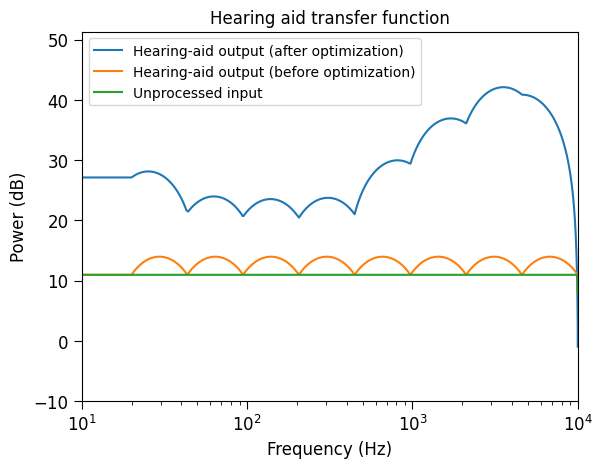

In [31]:
impulse = torch.zeros(int(hearing_aid.filterbank.sr)).to(device)
impulse[0] = 1
impulse_response = hearing_aid(impulse).detach().cpu().numpy()

before_hearing_aid = FrequencySpecificGainHearingAid(
    sr=dataset_train.sr,
    num_channels=hearing_aid.num_channels,
    initial_gain_db=0,
).to(device)
before_impulse_response = before_hearing_aid(impulse).detach().cpu().numpy()

fig, ax = plt.subplots()
fxx, pxx = utils.periodogram(impulse_response, sr)
ax.plot(fxx, pxx, label="Hearing-aid output (after optimization)")
fxx, pxx = utils.periodogram(before_impulse_response, sr)
ax.plot(fxx, pxx, label="Hearing-aid output (before optimization)")
fxx, pxx = utils.periodogram(impulse.detach().cpu().numpy(), sr)
ax.plot(fxx, pxx, label="Unprocessed input")
ax.legend()
ax = utils.format_axes(
    ax,
    str_title="Hearing aid transfer function",
    str_xlabel="Frequency (Hz)",
    str_ylabel="Power (dB)",
    xscale="log",
    xlimits=[10, sr // 2],
    ylimits=[-10, None],
)
plt.show()


Visualize and listen to the hearing-aid processed output.

/Users/marksa/Desktop/auditory_machine_learning/utils.py:152: RuntimeWarning: divide by zero encountered in log10
  pxx = 10.0 * np.log10(pxx / np.square(p_ref))


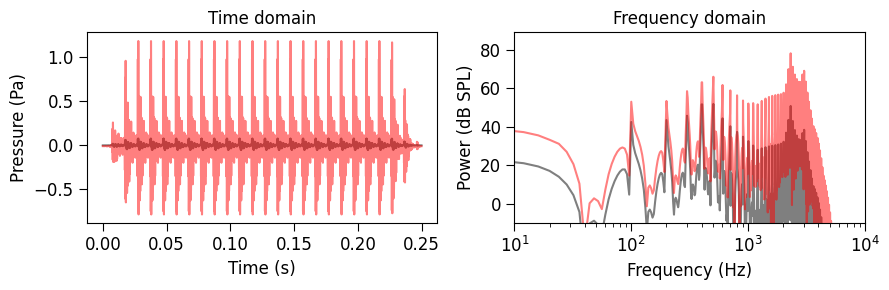

In [32]:
sr = dataset_train.sr
x_unprocessed = torch.as_tensor(dataset_train[0]["signal"]).to(device)
x_processed = hearing_aid(x_unprocessed)
x_unprocessed = x_unprocessed.detach().cpu().numpy()
x_processed = x_processed.detach().cpu().numpy()

fig, ax_arr = plt.subplots(nrows=1, ncols=2, figsize=(9, 3))
t = np.arange(0, len(x_unprocessed)) / sr
ax_arr[0].plot(t, x_unprocessed, color="k", alpha=0.5)
ax_arr[0].plot(t, x_processed, color="r", alpha=0.5)
ax_arr[0] = utils.format_axes(
    ax_arr[0],
    str_xlabel="Time (s)",
    str_ylabel="Pressure (Pa)",
    str_title="Time domain",
)
fxx, pxx = utils.periodogram(x_unprocessed, sr)
fyy, pyy = utils.periodogram(x_processed, sr)
ax_arr[1].plot(fxx, pxx, color="k", alpha=0.5)
ax_arr[1].plot(fyy, pyy, color="r", alpha=0.5)
ax_arr[1] = utils.format_axes(
    ax_arr[1],
    xscale="log",
    xlimits=[10, sr / 2],
    ylimits=[-10, None],
    str_xlabel="Frequency (Hz)",
    str_ylabel="Power (dB SPL)",
    str_title="Frequency domain",
)
plt.tight_layout()
plt.show()

# Play the unprocessed input, followed by the hearing-aid processed output
data = np.concatenate([
    x_unprocessed,
    np.zeros(int(0.25 * sr)),
    x_processed,
])
ipd.display(ipd.Audio(rate=sr, data=data))

# Play the unprocessed and processed audio, normalized to the same level
data = np.concatenate([
    x_unprocessed / np.abs(x_unprocessed).max(),
    np.zeros(int(0.25 * sr)),
    x_processed / np.abs(x_processed).max(),
])
ipd.display(ipd.Audio(rate=sr, data=data))


Visualize the effects of the optimized hearing aid processing on the auditory nerve representations.

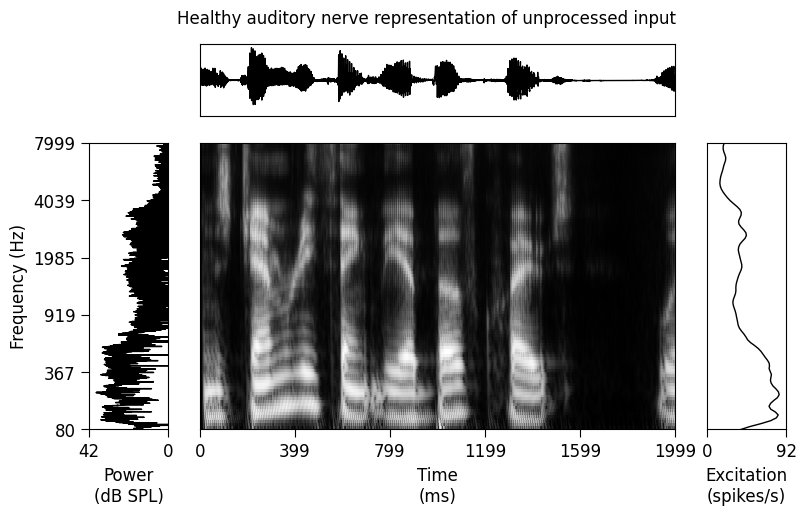

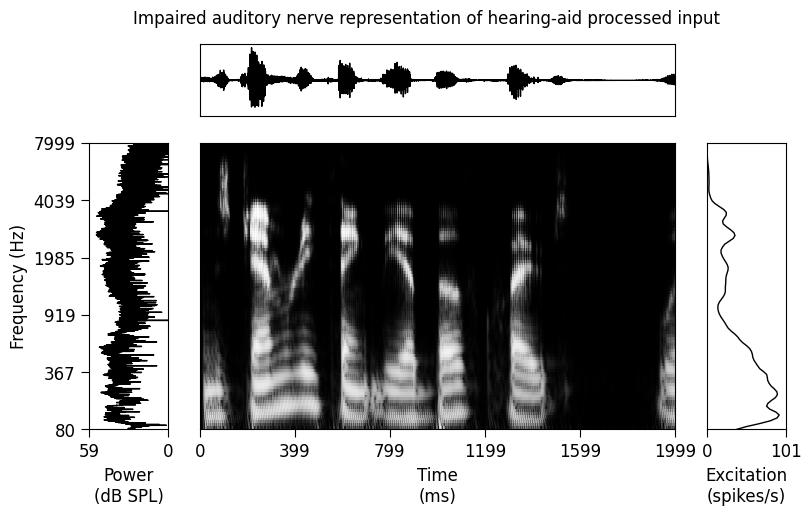

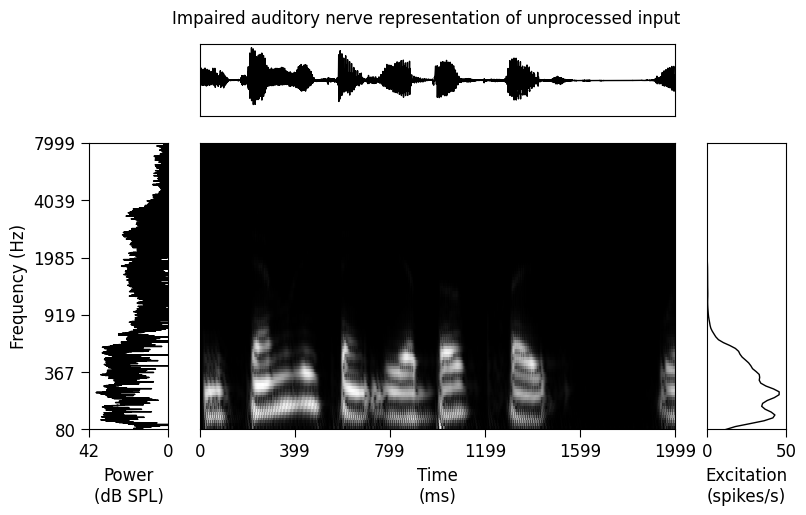

In [35]:
example_input = torch.as_tensor(example_datasets.WavFiles()[0]["signal"]).to(device)

fig, ax_arr = example_plots.visualize_cochlear_model(
    cochlear_model=cochlear_model_healthy,
    example_input=example_input,
    str_title="Healthy auditory nerve representation of unprocessed input",
)
fig, ax_arr = example_plots.visualize_cochlear_model(
    cochlear_model=cochlear_model_impaired,
    example_input=hearing_aid(example_input),
    str_title="Impaired auditory nerve representation of hearing-aid processed input",
)
fig, ax_arr = example_plots.visualize_cochlear_model(
    cochlear_model=cochlear_model_impaired,
    example_input=example_input,
    str_title="Impaired auditory nerve representation of unprocessed input",
)


Another way to achieve frequency-specific linear gain is with convolution in the time domain. The `ConvolutionalHearingAid` class below convolves its inputs with a learnable FIR filter kernel. Note that optimizing this hearing aid implementation is considerably less stable. Hyperparameters like the kernerl size, learning rate, and number of epochs may need to be tuned via trial-and-error.


In [36]:
class ConvolutionalHearingAid(torch.nn.Module):
    def __init__(self, kernel_size=51):
        """
        Initialize the hearing aid model.
        """
        super().__init__()
        self.conv = torch.nn.Conv1d(
            in_channels=1,
            out_channels=1,
            kernel_size=kernel_size,
            bias=False,
            padding=kernel_size // 2,
        )

    def forward(self, x):
        """
        Apply hearing aid processing to an input sound `x`.
        """
        input_ndim = x.ndim
        if x.ndim == 1:
            x = x.unsqueeze(0).unsqueeze(0)  # shape: [1, 1, time]
        elif x.ndim == 2:
            x = x.unsqueeze(1)  # shape: [batch, 1, time]
        else:
            raise ValueError("Input must have shape [time], [batch, time]")
        y = self.conv(x)
        if input_ndim == 1:
            return y.squeeze(0).squeeze(0)  # shape: [time]
        elif input_ndim == 2:
            return y.squeeze(1)  # shape: [batch, time]
        else:
            return y

    def __repr__(self):
        w = self.conv.weight.detach().cpu()
        return f"HearingAid(weight_mean={w.mean():.4f}, weight_std={w.std():.4f})"


dataset_train = example_datasets.WavFiles(filenames="data/00?.wav", dbspl=60)
dataloader_train = torch.utils.data.DataLoader(dataset_train, batch_size=8, shuffle=True)

hearing_aid = ConvolutionalHearingAid(kernel_size=51).to(device)
optimizer = torch.optim.Adam(
    params=hearing_aid.parameters(),
    lr=1e-1
)

print(f"Before optimization: {hearing_aid}\n\n")
progress_bar = tqdm.tqdm(range(20))
for epoch in progress_bar:
    loss = 0
    for step, example in enumerate(dataloader_train):
        x_unprocessed = example["signal"].to(device)
        x_processed = hearing_aid(x_unprocessed)
        batch_loss = cochlear_model_loss_function(x_unprocessed, x_processed)
        optimizer.zero_grad()
        batch_loss.backward()
        optimizer.step()
        loss += batch_loss.item()
        progress_bar.set_postfix({
            "loss": f"{loss / (step + 1):.2f}",
            "hearing_aid": str(hearing_aid),
        })
print(f"\n\nAfter optimization: {hearing_aid}")


Before optimization: HearingAid(weight_mean=0.0002, weight_std=0.0833)




100%|█████████████████████████████████████████████████████████████| 20/20 [01:14<00:00,  3.70s/it, loss=1012.94, hearing_aid=HearingAid(weight_mean=0.0489, weight_std=0.6414)]



After optimization: HearingAid(weight_mean=0.0489, weight_std=0.6414)


## Ideas for additional exploration

On first glance, the hearing aid with frequency-specific linear gains appears to do fairly well. The impaired auditory nerve representation of the hearing-aid-processed signal reasonably resembles the healthy auditory nerve representation of the unprocessed signal.

- But it is far from perfect -- linear amplification cannot compensate for the reduced dynamic range of the impaired ear. How might we design and optimize a hearing aid that further minimizes the loss function?

- In addition to elevating thresholds and reducing dynamic ranges, loss of OHCs also leads to broader cochlear frequency tuning. This can be simulated by specifying `bw_mult=(min_value, max_value)` as an argument to `modules.AudiogramMatchedCochlearModel`. How might a hearing aid compensate for this consequence of hearing loss?

- The "hearing aids" in this notebook are toy examples with simple signal processing and small numbers of parameters. With more compute power and a larger dataset, the same approach could be used to optimize more complex audio-processing systems, such as deep artificial neural networks. See [**`torchaudio.models`**](https://pytorch.org/audio/main/models.html) for ready-to-use PyTorch neural network models.

- Here, our optimization objective is to restore healthy auditory nerve representations in a very simple model of the impaired auditory nerve. Is this a good "loss function" for a hearing aid? How might we improve upon it?

## Appendix


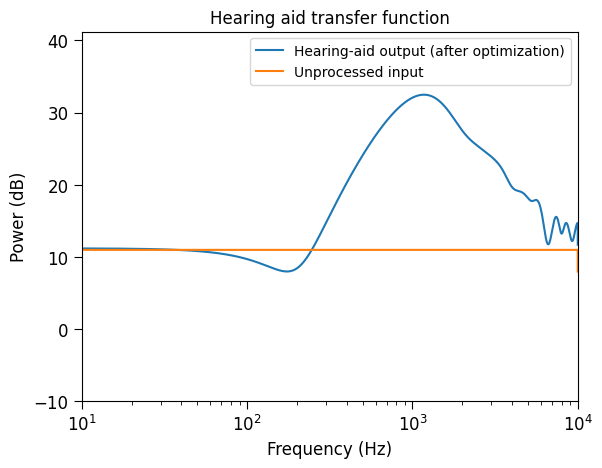

In [37]:
## Additional cell to plot hearing aid transfer function ##

sr = dataset_train.sr
impulse = torch.zeros(int(sr)).to(device)
impulse[0] = 1
impulse_response = hearing_aid(impulse).detach().cpu().numpy()

fig, ax = plt.subplots()
fxx, pxx = utils.periodogram(impulse_response, sr)
ax.plot(fxx, pxx, label="Hearing-aid output (after optimization)")
fxx, pxx = utils.periodogram(impulse.detach().cpu().numpy(), sr)
ax.plot(fxx, pxx, label="Unprocessed input")
ax.legend()
ax = utils.format_axes(
    ax,
    str_title="Hearing aid transfer function",
    str_xlabel="Frequency (Hz)",
    str_ylabel="Power (dB)",
    xscale="log",
    xlimits=[10, sr // 2],
    ylimits=[-10, None],
)
plt.show()


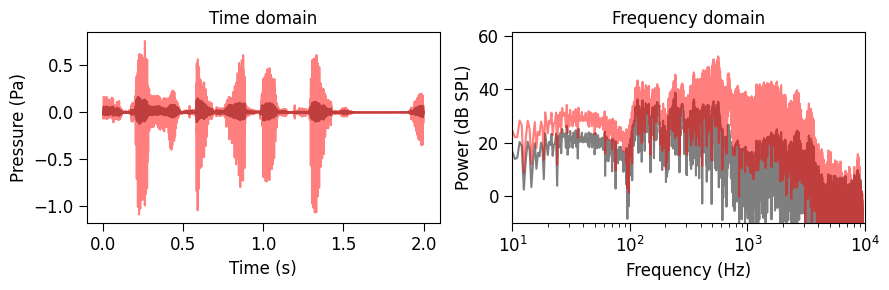

In [38]:
## Additional cell to visualize and listen to hearing aid output ##

sr = dataset_train.sr
x_unprocessed = torch.as_tensor(dataset_train[0]["signal"]).to(device)
x_processed = hearing_aid(x_unprocessed)
x_unprocessed = x_unprocessed.detach().cpu().numpy()
x_processed = x_processed.detach().cpu().numpy()

fig, ax_arr = plt.subplots(nrows=1, ncols=2, figsize=(9, 3))
t = np.arange(0, len(x_unprocessed)) / sr
ax_arr[0].plot(t, x_unprocessed, color="k", alpha=0.5)
ax_arr[0].plot(t, x_processed, color="r", alpha=0.5)
ax_arr[0] = utils.format_axes(
    ax_arr[0],
    str_xlabel="Time (s)",
    str_ylabel="Pressure (Pa)",
    str_title="Time domain",
)
fxx, pxx = utils.periodogram(x_unprocessed, sr)
fyy, pyy = utils.periodogram(x_processed, sr)
ax_arr[1].plot(fxx, pxx, color="k", alpha=0.5)
ax_arr[1].plot(fyy, pyy, color="r", alpha=0.5)
ax_arr[1] = utils.format_axes(
    ax_arr[1],
    xscale="log",
    xlimits=[10, sr / 2],
    ylimits=[-10, None],
    str_xlabel="Frequency (Hz)",
    str_ylabel="Power (dB SPL)",
    str_title="Frequency domain",
)
plt.tight_layout()
plt.show()

# Play the unprocessed input, followed by the hearing-aid processed output
data = np.concatenate([
    x_unprocessed,
    np.zeros(int(0.25 * sr)),
    x_processed,
])
ipd.display(ipd.Audio(rate=sr, data=data))

# Play the unprocessed and processed audio, normalized to the same level
data = np.concatenate([
    x_unprocessed / np.abs(x_unprocessed).max(),
    np.zeros(int(0.25 * sr)),
    x_processed / np.abs(x_processed).max(),
])
ipd.display(ipd.Audio(rate=sr, data=data))


In [ ]:
## Additional example of training a large DNN-based hearing aid (ConvTasNet)
import torchaudio


class ConvTasNetHearingAid(torch.nn.Module):
    def __init__(self, **args):
        """
        Initialize the hearing aid model.

        ConvTasNet arguments are defined in the PyTorch documentation:
        https://pytorch.org/audio/main/generated/torchaudio.models.ConvTasNet.html
        """
        super().__init__()
        self.convtasnet = torchaudio.models.ConvTasNet(**args)

    def forward(self, x):
        """
        Apply the computations to an input sound `x`.
        
        ConvTasNet, a neural network designed for source separation
        takes input with shape [batch, channel==1, time] and returns
        output with shape [batch, channel==num_sources, time]. Here,
        we simply return the first output source as our hearing aid
        processed audio.
        """
        input_ndim = x.ndim
        if x.ndim == 1:
            x = x.unsqueeze(0).unsqueeze(0)  # shape: [1, 1, time]
        elif x.ndim == 2:
            x = x.unsqueeze(1)  # shape: [batch, 1, time]
        else:
            raise ValueError("Input must have shape [time], [batch, time]")
        y = self.convtasnet(x)[:, 0, :]
        if input_ndim == 1:
            return y.squeeze(0)
        return y


dataset_train = example_datasets.WavFiles(filenames="data/???.wav", dbspl=60)
dataloader_train = torch.utils.data.DataLoader(dataset_train, batch_size=8, shuffle=True)
hearing_aid = ConvTasNetHearingAid().to(device)
count = 0
for p in hearing_aid.parameters():
    count += p.numel()
print(f"Attempting to optimize hearing_aid's {count:,} parameters:")

optimizer = torch.optim.Adam(
    params=hearing_aid.parameters(),
    lr=1e-3,
)
progress_bar = tqdm.tqdm(range(10))
for epoch in progress_bar:
    loss = 0
    for step, example in enumerate(dataloader_train):
        x_unprocessed = example["signal"].to(device)
        x_processed = hearing_aid(x_unprocessed)
        batch_loss = cochlear_model_loss_function(x_unprocessed, x_processed)
        optimizer.zero_grad()
        batch_loss.backward()
        optimizer.step()
        loss += batch_loss.item()
        progress_bar.set_postfix({
            "loss": f"{loss / (step + 1):.2f}",
        })


In [150]:
# class VowelClassifierModel(torch.nn.Module):
#     def __init__(self, n_classes=10):
#         """
#         Initialize the vowel classifier model.
#         """
#         super().__init__()
#         self.neural_network = torch.nn.Sequential(
#             torch.nn.Conv1d(1, 32, kernel_size=51, stride=4, padding="valid"),
#             torch.nn.ReLU(),
#             torch.nn.Conv1d(32, 64, kernel_size=51, stride=8, padding="valid"),
#             torch.nn.ReLU(),
#             torch.nn.Conv1d(64, 128, kernel_size=51, stride=16, padding="valid"),
#             torch.nn.ReLU(),
#             torch.nn.AdaptiveAvgPool1d(1),
#             torch.nn.Flatten(),
#             torch.nn.Linear(128, n_classes)
#         )

#     def forward(self, x):
#         """
#         Run classifier model on an input sound `x`.
#         """
#         if x.ndim == 1:
#             x = x[None, None, :]
#         elif x.ndim == 2:
#             x = x[:, None, :]
#         assert x.ndim == 3
#         return self.neural_network(x)


class VowelClassifierModel(torch.nn.Module):
    def __init__(self, n_classes=10):
        """
        Initialize the vowel classifier model.
        """
        super().__init__()
        self.cochlear_model = modules.AudiogramMatchedCochlearModel(
            audiogram="ref",
            **config_cochlear_model,
        )
        self.neural_network = torch.nn.Sequential(
            # torch.nn.Conv2d(1, 16, kernel_size=[1, 15], stride=[1, 10], padding="valid"),
            # torch.nn.ReLU(),
            # torch.nn.Conv2d(16, 32, kernel_size=[15, 1], stride=[2, 5], padding="valid"),
            # torch.nn.ReLU(),
            # torch.nn.Conv2d(32, 64, kernel_size=[5, 5], stride=[2, 2], padding="valid"),
            # torch.nn.ReLU(),
            # torch.nn.AdaptiveAvgPool2d((1, 1)),
            torch.nn.Flatten(),
            torch.nn.LazyLinear(64),
            torch.nn.ReLU(),
            torch.nn.Linear(64, 64),
            torch.nn.ReLU(),
            torch.nn.Linear(64, n_classes),
        )

    def forward(self, x):
        """
        Run classifier model on an input sound `x`.
        """
        if x.ndim == 1:
            x = x[None, :]
        assert x.ndim == 2
        x = self.cochlear_model(x)
        x = x[:, None, :, :]
        assert x.ndim == 4
        x = self.neural_network(x)
        assert x.ndim == 2
        return x


dataset_train = example_datasets.SyntheticVowels(f0=(100, 400), dbspl=(30, 90), n_examples=1000)
dataloader_train = torch.utils.data.DataLoader(dataset_train, batch_size=16, shuffle=True)

model = VowelClassifierModel().to(device)
optimizer = torch.optim.Adam(params=model.parameters(), lr=1e-3)
loss_function = torch.nn.CrossEntropyLoss()

progress_bar = tqdm.tqdm(range(10))
for epoch in progress_bar:
    loss = 0
    accuracy = 0
    for step, example in enumerate(dataloader_train):
        x = example["signal"].to(device)
        y_true = example["vowel"].to(device)
        y_pred = model(x)
        batch_loss = loss_function(y_pred, y_true)
        batch_accuracy = (y_pred.argmax(dim=1) == y_true).float().mean()
        optimizer.zero_grad()
        batch_loss.backward()
        optimizer.step()
        loss += batch_loss.item()
        accuracy += batch_accuracy.item()
        progress_bar.set_postfix({
            "loss": f"{loss / (step + 1):.2f}",
            "accuracy": f"{accuracy / (step + 1):.3f}",
        })



00%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████| 10/10 [02:02<00:00, 12.20s/it, loss=1.29, accuracy=0.802]


3it [00:12,  5.24it/s]

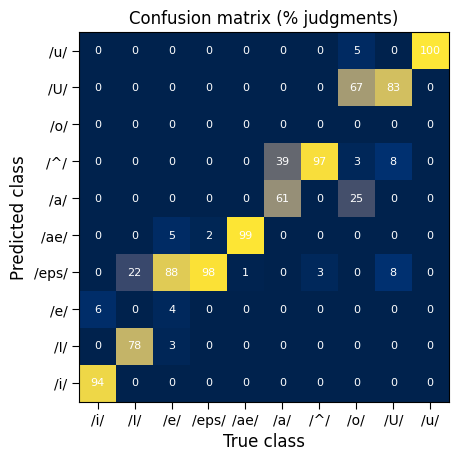

In [151]:
dataset_valid = example_datasets.SyntheticVowels(f0=(220, 220), dbspl=(90, 90), n_examples=1000)
dataloader_valid = torch.utils.data.DataLoader(dataset_train, batch_size=16, shuffle=False)

list_y_true = []
list_y_pred = []
for step, example in tqdm.tqdm(enumerate(dataloader_train)):
    x = example["signal"].to(device)
    y_true = example["vowel"]
    y_pred = model(x).argmax(dim=1)
    list_y_true.extend(y_true.detach().cpu().numpy().tolist())
    list_y_pred.extend(y_pred.detach().cpu().numpy().tolist())

fig, ax = plt.subplots()
confusion_matrix = np.zeros((10, 10), dtype=int)
for y_true, y_pred in zip(list_y_true, list_y_pred):
    confusion_matrix[y_pred, y_true] += 1
confusion_matrix = confusion_matrix / np.sum(confusion_matrix, axis=0)
im = ax.imshow(confusion_matrix, cmap="cividis", origin="lower")
ticks = np.arange(10)
ticklabels = [dataset_valid.map_vowel_to_str[_].split(" ")[0] for _ in ticks]
ax = utils.format_axes(
    ax,
    str_title="Confusion matrix (% judgments)",
    str_xlabel="True class",
    str_ylabel="Predicted class",
    xticks=ticks,
    yticks=ticks,
    xticklabels=ticklabels,
    yticklabels=ticklabels,
    fontsize_ticks=10,
)
for i in range(10):
    for j in range(10):
        ax.text(
            j,
            i,
            f"{100 * confusion_matrix[i, j]:.0f}",
            ha="center",
            va="center",
            color="w",
            fontsize=8,
        )
plt.show()
